# PCA analysis

## Objective

The objective of this notebook is to identify the dominant latent factors driving the joint behavior of EUR/USD and GBP/USD daily returns using Principal Component Analysis (PCA).

PCA is employed as a dimensionality reduction technique that transforms correlated return series into a set of orthogonal components, these components represents the main sources of variations in the data and provide a factor-based representation of the FX market.

The results obtained in this notebook will serve as the foundation for the development of the trading strategy.

One question to answer troughout this notebook is: 

**Can the joint dynamics of EUR/USD and GBP/USD returns be summarized by a small number of latent factors?**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [2]:
# Data loading 
eurusd = pd.read_csv("../data/raw/EURUSD.csv")
gbpusd = pd.read_csv("../data/raw/GBPUSD.csv")

# Dates need to be aligned
eurusd["date"] = pd.to_datetime(eurusd["date"])
gbpusd["date"] = pd.to_datetime(gbpusd["date"])


eurusd_clean = eurusd[["date", "close"]].rename(
    columns={"close": "EURUSD"}
)

gbpusd_clean = gbpusd[["date", "close"]].rename(
    columns={"close": "GBPUSD"}
)


prices = pd.merge(
    eurusd_clean,
    gbpusd_clean,
    on="date",
    how="inner"
)


prices = prices.sort_values("date").set_index("date")

prices.head()

,EURUSD,GBPUSD
date,,
2010-01-26,1.40808,1.61425
2010-01-27,1.40280,1.61755
2010-01-28,1.39620,1.61415
2010-01-29,1.38605,1.59883
2010-02-01,1.39200,1.59440


In [3]:
# Compute the returns
returns = np.log(prices / prices.shift(1)).dropna()
returns.head() 

,EURUSD,GBPUSD
date,,
2010-01-27,-0.003757,0.002042
2010-01-28,-0.004716,-0.002104
2010-01-29,-0.007296,-0.009536
2010-02-01,0.004284,-0.002775
2010-02-02,0.003850,0.002787


In [4]:
pca = PCA(n_components=2)

In [5]:
# Apply PCA to log-returns
pca.fit(returns)
pca.explained_variance_ratio_

array([0.81187046, 0.18812954])

Text(0.5, 1.0, 'Variance explained by 2 principal components')

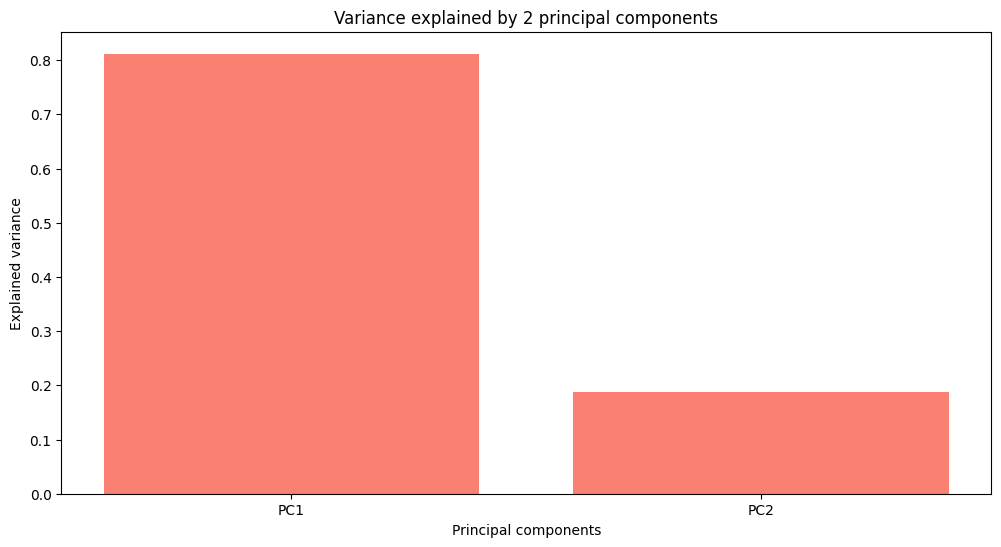

In [6]:
# Let's visualize how much variance is explained by the two components
plt.figure(figsize=(12,6))
plt.bar(["PC1", "PC2"], pca.explained_variance_ratio_, color="salmon")
plt.ylabel("Explained variance")
plt.xlabel("Principal components")
plt.title("Variance explained by 2 principal components")

The first principal component explains approximately 81% of the total variance, indicating that a single latent factor captures most of the joint variation between EUR/USD and GBP/USD returns, note that the sum of the variance explained ratio of the two components is 1, in other words, the two components explained the variance totally.

In [7]:
loadings = pd.DataFrame({
    "EURUSD":[pca.components_[0][0], pca.components_[0][1]],
    "GBPUSD":[pca.components_[1][0], pca.components_[1][1]]
}, index=["PC1", "PC2"])

loadings

,EURUSD,GBPUSD
PC1,0.681350,0.731958
PC2,0.731958,-0.681350


The first principal component captures the dominant common movement shared by EUR/USD and GBP/USD returns. Since both exchange rates share the US Dollar as the quote currency, this component is consistent with a common market factor affecting both series.

The second principal component measure the relative difference on both pairs, note the sign un the second principal component, this component is higher if EUR/USD goes up and GBP/USD goes down, if GBP/USD goes up and EUR/USD goes down, the component is lower, in other words, the second principal component measures how much divergence exist between the two pairs.

Now we need to analyze the scores, this is fundamental for the trading strategy to be implemented later.

The score is a computation using the loadings of PCA, this gives us a score of how much strong is each principal component on each day, this can be helpful to identify changes of market regimes.

In [8]:
# Projection of returns onto principal components
scores = pca.fit_transform(returns)

In [9]:
scores_df = pd.DataFrame(scores, columns=["PC1_score", "PC2_score"], index=returns.index)
returns = pd.concat([returns, scores_df], axis=1)
returns.head()

,EURUSD,GBPUSD,PC1_score,PC2_score
date,,,,
2010-01-27,-0.003757,0.002042,-0.001006,-0.004138
2010-01-28,-0.004716,-0.002104,-0.004695,-0.002015
2010-01-29,-0.007296,-0.009536,-0.011893,0.001160
2010-02-01,0.004284,-0.002775,0.000946,0.005029
2010-02-02,0.003850,0.002787,0.004722,0.000922


Text(0, 0.5, 'PC2 Score')

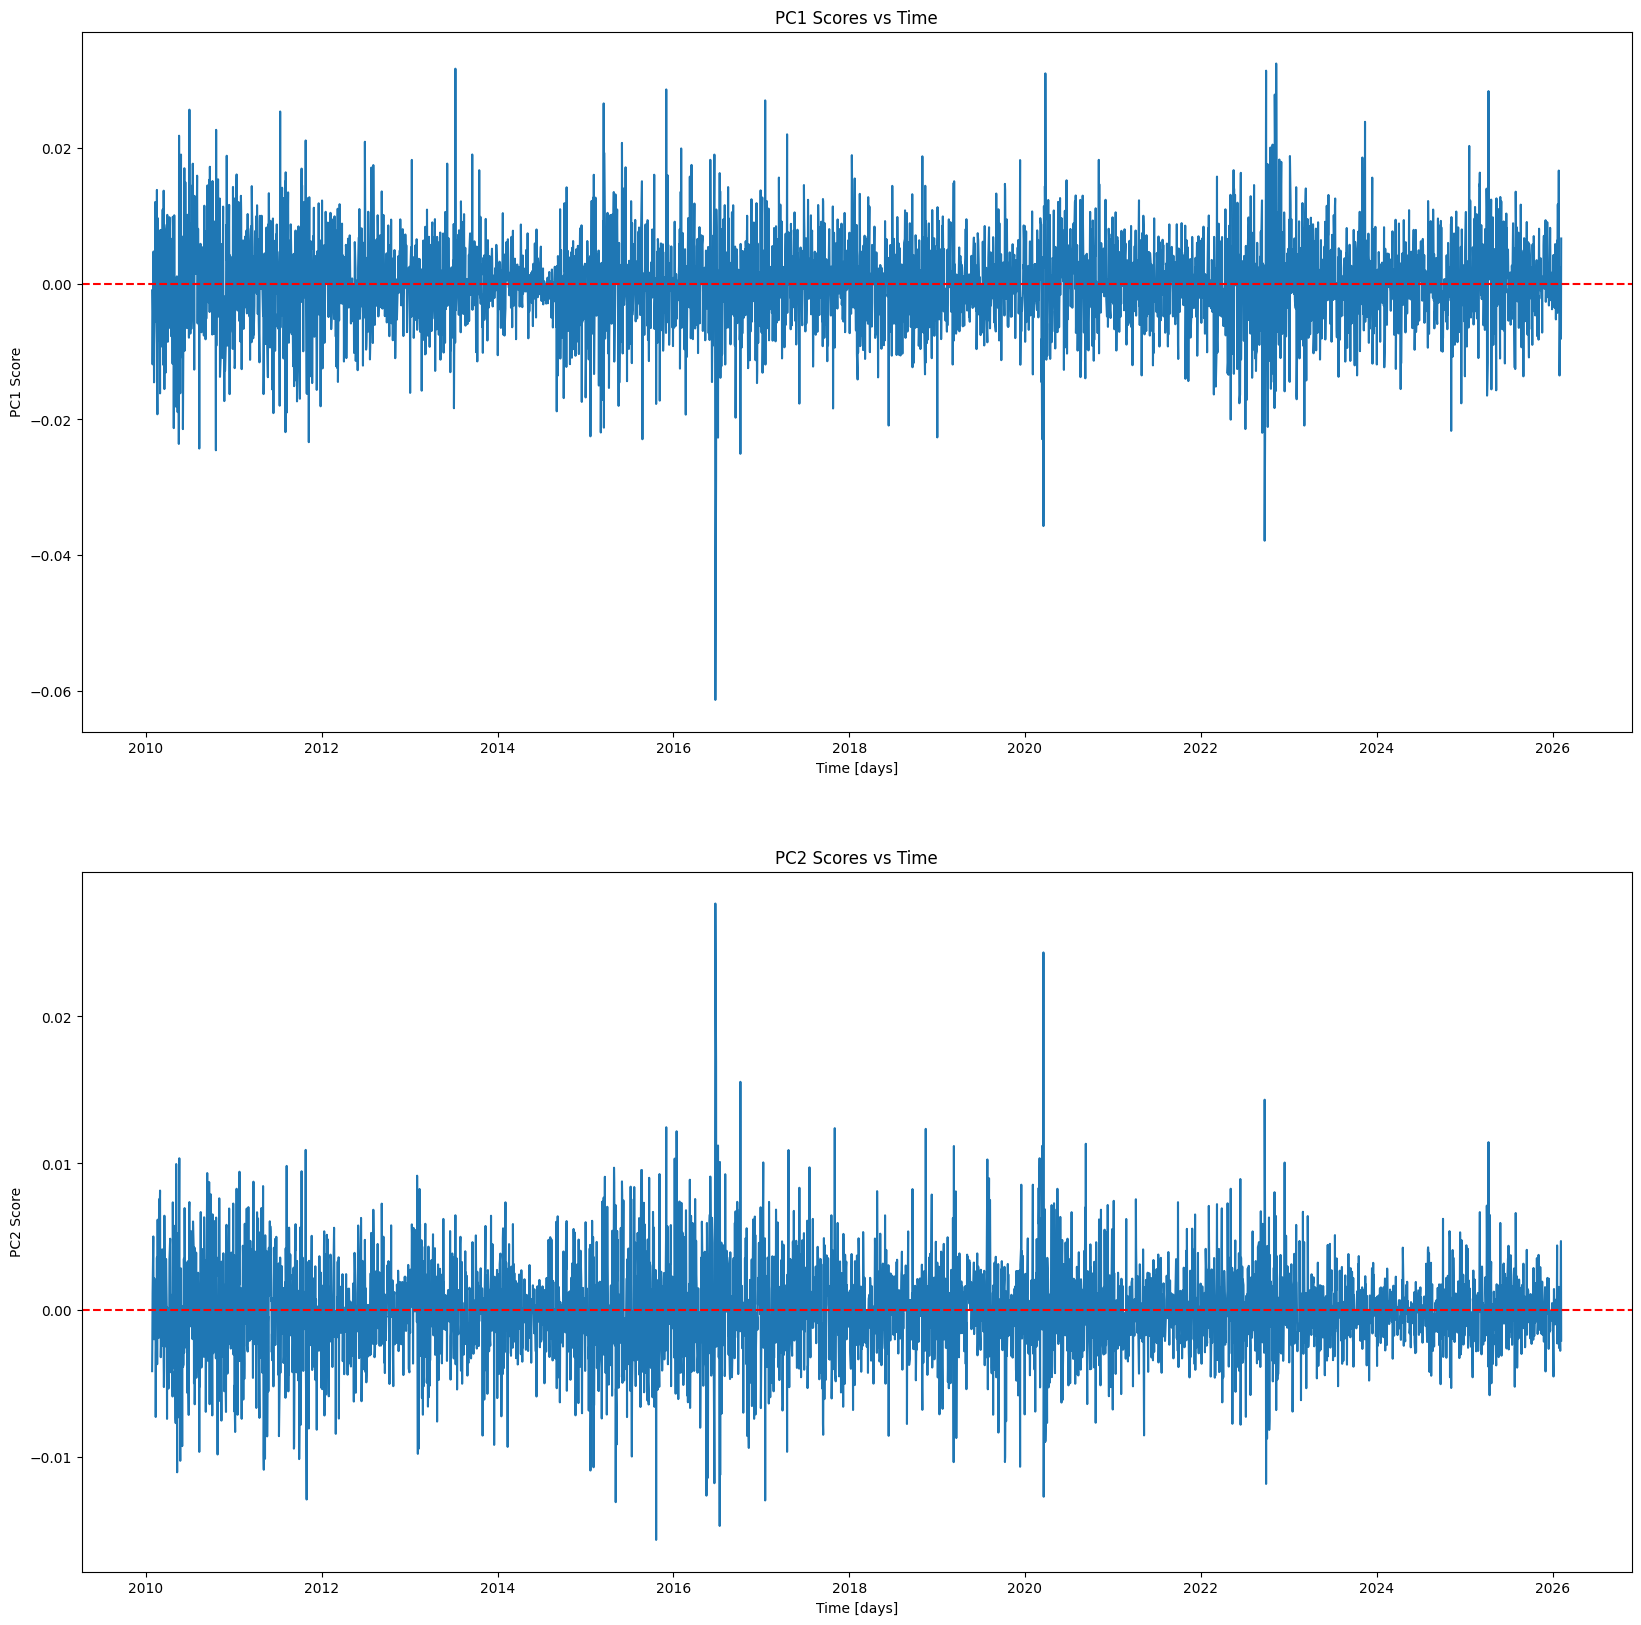

In [33]:
# Let's visualize the principal components over time
fig, ax = plt.subplots(nrows=2, figsize=(20, 20))
pc1_ax = ax[0]
pc2_ax = ax[1]

pc1_ax.plot(returns["PC1_score"])
pc1_ax.axhline(y=0, color="red", linestyle="--")
pc1_ax.set_title("PC1 Scores vs Time")
pc1_ax.set_xlabel("Time [days]")
pc1_ax.set_ylabel("PC1 Score")

pc2_ax.plot(returns["PC2_score"])
pc2_ax.axhline(y=0, color="red", linestyle="--")
pc2_ax.set_title("PC2 Scores vs Time")
pc2_ax.set_xlabel("Time [days]")
pc2_ax.set_ylabel("PC2 Score")

Let's see some statistical information about the scores

In [18]:
returns[["PC1_score", "PC2_score"]].describe().loc["mean"]

PC1_score   -1.459772e-19
PC2_score   -1.244124e-20
Name: mean, dtype: float64

We can observe that the mean of both scores is almost zero.

Text(0, 0.5, 'Frequency')

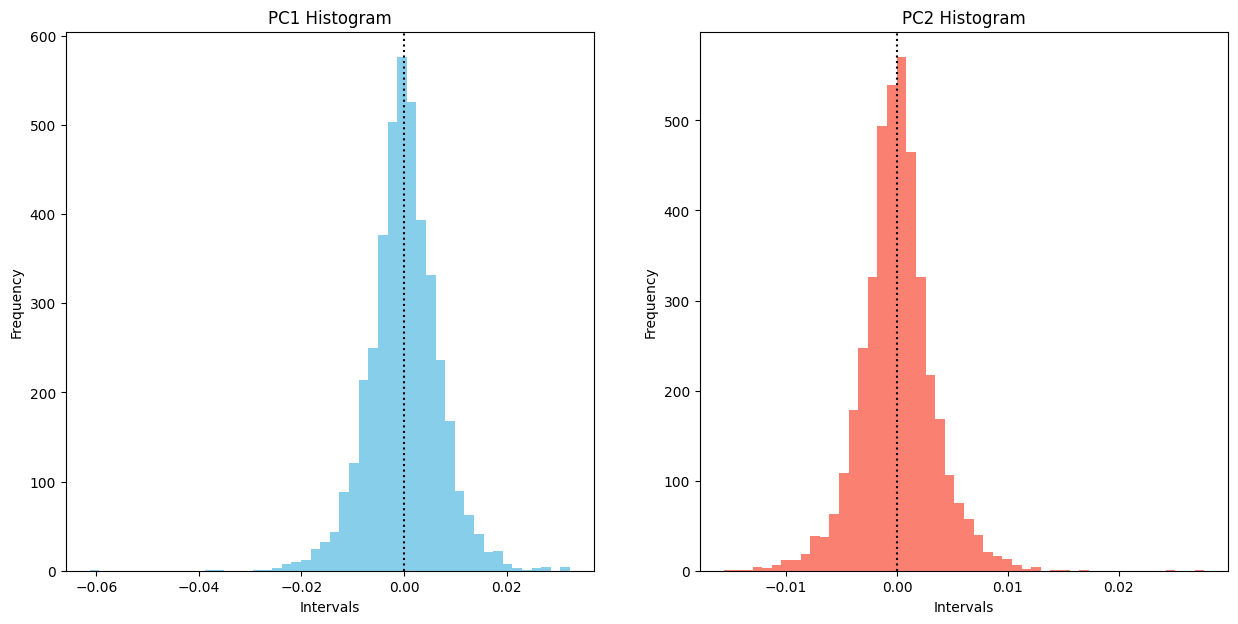

In [31]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 7))
pc1_ax = ax[0]
pc2_ax = ax[1]

pc1_ax.hist(returns["PC1_score"], bins=50, color="skyblue")
pc2_ax.hist(returns["PC2_score"], bins=50, color="salmon")
pc1_ax.axvline(0, color="black", linestyle=":")
pc2_ax.axvline(0, color="black", linestyle=":")


pc1_ax.set_title("PC1 Histogram")
pc2_ax.set_title("PC2 Histogram")
pc1_ax.set_xlabel("Intervals")
pc1_ax.set_ylabel("Frequency")
pc2_ax.set_xlabel("Intervals")
pc2_ax.set_ylabel("Frequency")

The histograms of the scores of principal components scores appear to approximately symmetric and bell-shaped, suggesting that their empirical distributions are reasonably close to a Gaussian distribution.